# Expanded LSEG Gemma publisher conditioning

**Question.** On the separate 44-company LSEG/Gemma robustness spine, does
conditioning headline sentiment on the only defensible named publisher class
(Reuters) improve next-open return relevance or after-cost performance?

**Frozen before opening this arm's returns.** The primary family is exactly
four h1 signals: all-source mean, Reuters-only mean, non-Reuters-only mean,
and an ex-ante Reuters-2× weighted mean. Reuters means `source_code ==
"NS:RTRS"`; the other 3,000+ opaque codes remain one unresolved non-Reuters
pool. Source-specific arms use that source class's earliest observed
timestamp. IC is mean daily cross-sectional Spearman with HAC(5), with BH once
across four tests. Portfolios use centred cross-sectional ranks, gross
exposure one, at least ten names, 10 bps per side, explicit final liquidation,
and a 1,999-replication five-session circular block bootstrap.

**Success gate.** A result is economically viable only if its IC survives BH,
net Sharpe is positive, break-even cost is at least 10 bps per side, and the
bootstrap lower bound for mean net return is positive.

**Status and non-goals.** This is retrospective, non-pooled LSEG robustness on
an already-open eight-month window. It does not repair missing FNSPID
publisher metadata, establish publisher prestige, justify return-derived
tiers, or create a pristine holdout.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.lseg_expanded import (  # noqa: E402
    load_price_exports,
    load_success_scores,
)
from final_experiments.lib.lseg_publishers import (  # noqa: E402
    PUBLISHER_ARMS,
    PUBLISHER_BOOTSTRAP_REPLICATIONS,
    PUBLISHER_COST_BPS_PER_SIDE,
    PUBLISHER_PRIMARY_FAMILY,
    PUBLISHER_SEED,
    REUTERS_SOURCE_CODE,
    build_publisher_panels,
    evaluate_publisher_arms,
    load_headline_source_features,
)
from final_experiments.lib.plots import (  # noqa: E402
    CATEGORICAL,
    INK,
    STATUS,
    apply_house_style,
    display_label,
)

COLLECTION_ROOT = REPO_ROOT / "Data/collections/lseg_us_sector_44_8m_headlines/derived"
GEMMA_SCORES = (
    COLLECTION_ROOT
    / "headline_scores_gemma4_26b_a4b_it_deepinfra_fp8_investor_headline_soft_label_v1.csv"
)
MERGED_HEADLINES = COLLECTION_ROOT / "merged/headlines.jsonl"
SECTOR33_PRICES = REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_8m.csv"
ADD11_PRICES = REPO_ROOT / "Data/derived/prices/lseg_us_sector_add11_8m.csv"
REFERENCE_RESULTS = (
    REPO_ROOT
    / "final_experiments/outputs/13_lseg_44_gemma_robustness/primary_18_arm_results.csv"
)
OUTPUT = REPO_ROOT / "final_experiments/outputs/15_lseg_gemma_publisher_conditioning"
OUTPUT.mkdir(parents=True, exist_ok=True)
apply_house_style()

print("status: retrospective expanded-LSEG robustness; never pooled with FNSPID")
print("primary family:", PUBLISHER_PRIMARY_FAMILY)
print("named publisher class:", REUTERS_SOURCE_CODE)
print("arms:", PUBLISHER_ARMS)
print(f"cost: {PUBLISHER_COST_BPS_PER_SIDE:.1f} bps/side")

status: retrospective expanded-LSEG robustness; never pooled with FNSPID
primary family: four predeclared expanded-LSEG Gemma publisher signals x h1; daily cross-sectional IC, BH-FDR q=0.05
named publisher class: NS:RTRS
arms: ('all_source_mean', 'reuters_only_mean', 'non_reuters_only_mean', 'reuters_2x_mean')
cost: 10.0 bps/side


## 1. Reconcile the scored hash population to source metadata

Licensed headlines are streamed locally only to reconstruct their frozen
normalised hashes. No headline text is retained or written. The source-code
inventory is descriptive metadata; code labels are not interpreted as
prestige categories.

In [2]:
gemma, score_audit = load_success_scores(GEMMA_SCORES, scorer="gemma4_26b")
source_features, source_audit = load_headline_source_features(
    MERGED_HEADLINES,
    expected_hashes=set(gemma["headline_sha256"]),
)
prices = load_price_exports(SECTOR33_PRICES, ADD11_PRICES)

source_counts = (
    pd.Series(source_audit["source_row_counts"], name="corpus_rows")
    .rename_axis("source_code")
    .reset_index()
    .sort_values(["corpus_rows", "source_code"], ascending=[False, True])
)
hash_coverage = pd.DataFrame(
    [
        {
            key: value
            for key, value in source_audit.items()
            if key != "source_row_counts"
        }
    ]
)
hash_coverage["reuters_hash_share"] = (
    hash_coverage["hashes_with_reuters"]
    / hash_coverage["successful_hashes_mapped"]
)
hash_coverage["non_reuters_hash_share"] = (
    hash_coverage["hashes_with_non_reuters"]
    / hash_coverage["successful_hashes_mapped"]
)
hash_coverage.to_csv(OUTPUT / "source_hash_coverage.csv", index=False)
source_counts.to_csv(OUTPUT / "source_code_counts.csv", index=False)
display(hash_coverage.style.format({"reuters_hash_share": "{:.2%}", "non_reuters_hash_share": "{:.2%}"}))
display(source_counts.head(20))

,rows_read,unexpected_hash_rows,successful_hashes_mapped,hashes_with_reuters,hashes_with_non_reuters,hashes_with_both,distinct_source_codes,corpus_sha256,reuters_hash_share,non_reuters_hash_share
0,1158762,66,888155,33250,857461,2556,3112,7f48c46690f3293cbfe846ddecc701852daf3c35643f2747dcbc39f829927878,3.74%,96.54%


,source_code,corpus_rows
1304,NS:GLORDP,226195
3111,NS:X,80758
3025,NS:EDG,45837
1301,NS:NEWBTS,45609
1359,NS:CNBSTR,38633
1302,NS:GLOSTK,36493
3004,NS:RTRS,34381
1,NS:YAHNEX,30307
2542,NS:NEWNYS,23676
1303,NS:NOTENG,18989


findfont: Failed to find font weight medium, now using 400.


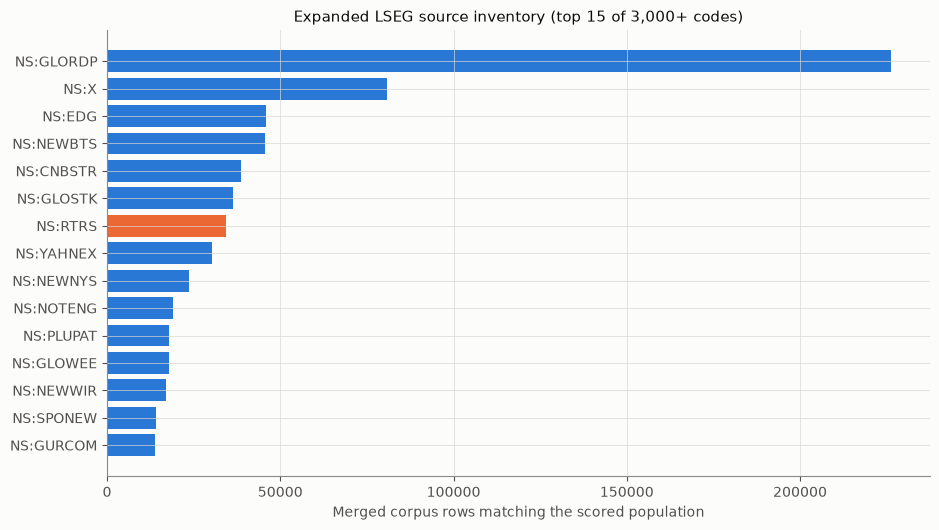

In [3]:
top = source_counts.head(15).iloc[::-1]
colours = [
    CATEGORICAL[1] if code == REUTERS_SOURCE_CODE else CATEGORICAL[0]
    for code in top["source_code"]
]
fig, ax = plt.subplots(figsize=(9.5, 5.4))
ax.barh(top["source_code"], top["corpus_rows"], color=colours)
ax.set_xlabel("Merged corpus rows matching the scored population")
ax.set_title("Expanded LSEG source inventory (top 15 of 3,000+ codes)")
fig.tight_layout()
fig.savefig(OUTPUT / "source_code_inventory.png", dpi=160, bbox_inches="tight")
plt.show()

Reuters is a small part of the all-source headline population, which makes
coverage and breadth diagnostics binding. No claim about the opaque source
codes is made beyond “non-Reuters”.

## 2. Build the four frozen source-conditioned panels

All-source and Reuters-2× use each hash's canonical earliest timestamp.
Reuters-only and non-Reuters-only use their own source class's earliest
timestamp, preventing another source's earlier publication from granting
impossible execution timing.

,arm,unique_headline_company_associations,firm_open_rows,priced_firm_open_rows,symbols,entry_sessions,mean_headlines_per_firm_open
0,all_source_mean,929691,7348,7348,44,167,126.52
1,reuters_only_mean,43791,5185,5185,44,167,8.45
2,non_reuters_only_mean,888918,7348,7348,44,167,120.97
3,reuters_2x_mean,929691,7348,7348,44,167,126.52


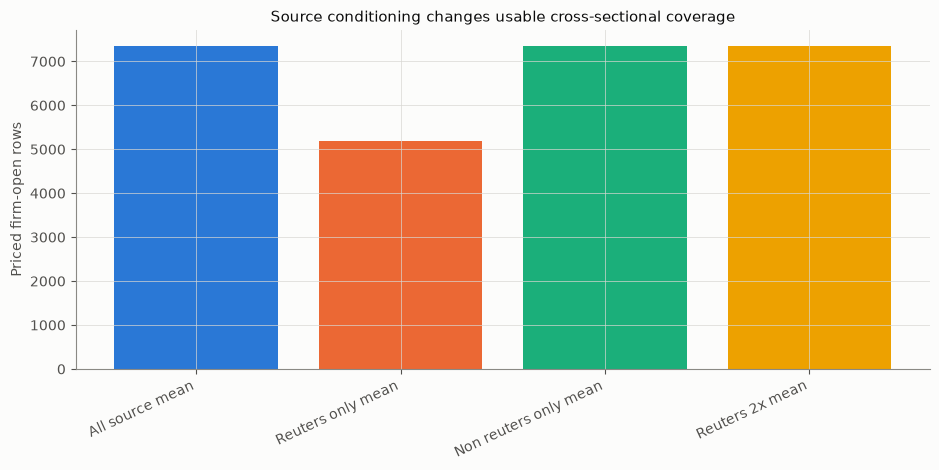

In [4]:
panels, panel_coverage = build_publisher_panels(gemma, source_features, prices)
panel_coverage.to_csv(OUTPUT / "publisher_panel_coverage.csv", index=False)
display(panel_coverage.style.format({"mean_headlines_per_firm_open": "{:.2f}"}))

fig, ax = plt.subplots(figsize=(9.5, 4.8))
x = np.arange(len(panel_coverage))
ax.bar(x, panel_coverage["priced_firm_open_rows"], color=CATEGORICAL[:4])
ax.set_xticks(x, [display_label(value) for value in panel_coverage["arm"]], rotation=25, ha="right")
ax.set_ylabel("Priced firm-open rows")
ax.set_title("Source conditioning changes usable cross-sectional coverage")
fig.tight_layout()
fig.savefig(OUTPUT / "publisher_panel_coverage.png", dpi=160, bbox_inches="tight")
plt.show()

## 3. Frozen four-arm return evaluation

Notebook 13's Gemma all-source mean is used only as a reproducibility check.
It is also the declared baseline inside this four-arm family; no arm is chosen
before BH and economic diagnostics are shown.

In [5]:
results, daily_outputs = evaluate_publisher_arms(
    panels,
    cost_bps_per_side=PUBLISHER_COST_BPS_PER_SIDE,
    bootstrap_replications=PUBLISHER_BOOTSTRAP_REPLICATIONS,
    seed=PUBLISHER_SEED,
)
results.to_csv(OUTPUT / "primary_4_arm_results.csv", index=False)
for arm, daily in daily_outputs.items():
    daily.to_csv(OUTPUT / f"daily_{arm}.csv", index=False)

show = [
    "arm",
    "ic",
    "ic_se",
    "ic_p",
    "bh_reject_ic_q05",
    "sharpe_gross",
    "sharpe_net",
    "breakeven_bps_per_side",
    "bootstrap_net_ci_low",
    "bootstrap_net_ci_high",
    "economically_viable",
]
display(results[show].sort_values("ic_p").style.format(precision=4))

,arm,ic,ic_se,ic_p,bh_reject_ic_q05,sharpe_gross,sharpe_net,breakeven_bps_per_side,bootstrap_net_ci_low,bootstrap_net_ci_high,economically_viable
1,reuters_only_mean,-0.0213,0.0162,0.1888,False,-1.3246,-6.2899,-2.6582,-0.0023,-0.0011,False
3,reuters_2x_mean,-0.0157,0.0175,0.3705,False,-1.2001,-4.2311,-3.9937,-0.0022,-0.0006,False
0,all_source_mean,-0.0151,0.0177,0.3937,False,-1.1897,-4.1952,-3.9917,-0.0022,-0.0006,False
2,non_reuters_only_mean,-0.0130,0.0177,0.4626,False,-1.1027,-4.1363,-3.6627,-0.0022,-0.0006,False


In [6]:
reference_all = pd.read_csv(REFERENCE_RESULTS)
reference = reference_all.loc[
    reference_all["scorer"].eq("gemma4_26b")
    & reference_all["aggregator"].eq("mean_continuous")
]
if len(reference) != 1:
    raise ValueError("Notebook 13 Gemma mean-continuous reference is not unique")
baseline = results.loc[results["arm"].eq("all_source_mean")].iloc[0]
reproduction = pd.DataFrame(
    [
        {
            "metric": metric,
            "notebook13": float(reference.iloc[0][metric]),
            "notebook15": float(baseline[metric]),
            "absolute_difference": abs(
                float(reference.iloc[0][metric]) - float(baseline[metric])
            ),
        }
        for metric in (
            "ic",
            "sharpe_gross",
            "sharpe_net",
            "breakeven_bps_per_side",
        )
    ]
)
if not np.allclose(
    reproduction["notebook13"], reproduction["notebook15"], atol=1e-12, rtol=0
):
    raise ValueError("all-source baseline does not reproduce Notebook 13")
reproduction.to_csv(OUTPUT / "notebook13_reproduction_check.csv", index=False)
display(reproduction)

,metric,notebook13,notebook15,absolute_difference
0,ic,-0.015077,-0.015077,5.898060e-17
1,sharpe_gross,-1.189725,-1.189725,0.000000e+00
2,sharpe_net,-4.195204,-4.195204,0.000000e+00
3,breakeven_bps_per_side,-3.991739,-3.991739,0.000000e+00


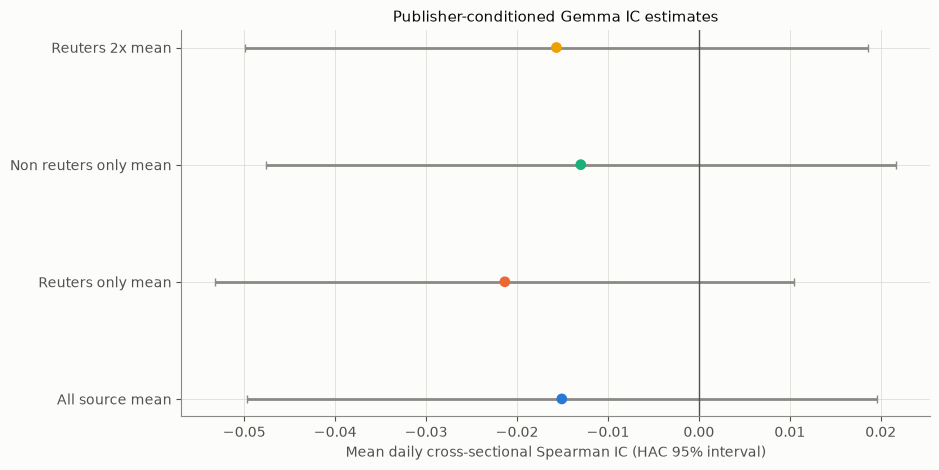

In [7]:
plot_results = results.set_index("arm").loc[list(PUBLISHER_ARMS)].reset_index()
labels = [display_label(value) for value in plot_results["arm"]]
y = np.arange(len(plot_results))
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.errorbar(
    plot_results["ic"],
    y,
    xerr=1.96 * plot_results["ic_se"],
    fmt="none",
    ecolor=INK["muted"],
    capsize=3,
)
ax.scatter(plot_results["ic"], y, c=CATEGORICAL[:4], s=45, zorder=3)
ax.axvline(0, color=INK["reference"], linewidth=1)
ax.set_yticks(y, labels)
ax.set_xlabel("Mean daily cross-sectional Spearman IC (HAC 95% interval)")
ax.set_title("Publisher-conditioned Gemma IC estimates")
fig.tight_layout()
fig.savefig(OUTPUT / "publisher_ic_intervals.png", dpi=160, bbox_inches="tight")
plt.show()

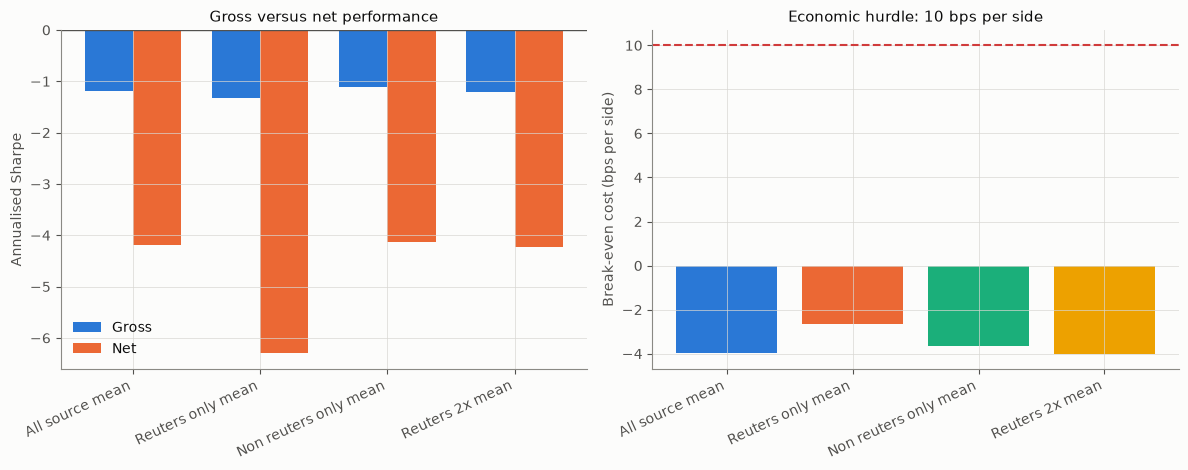

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
x = np.arange(len(plot_results))
axes[0].bar(x - 0.19, plot_results["sharpe_gross"], width=0.38, color=CATEGORICAL[0], label="Gross")
axes[0].bar(x + 0.19, plot_results["sharpe_net"], width=0.38, color=CATEGORICAL[1], label="Net")
axes[0].axhline(0, color=INK["reference"], linewidth=1)
axes[0].set_xticks(x, labels, rotation=25, ha="right")
axes[0].set_ylabel("Annualised Sharpe")
axes[0].set_title("Gross versus net performance")
axes[0].legend()

axes[1].bar(x, plot_results["breakeven_bps_per_side"], color=CATEGORICAL[:4])
axes[1].axhline(PUBLISHER_COST_BPS_PER_SIDE, color=STATUS["critical"], linestyle="--", linewidth=1.5)
axes[1].set_xticks(x, labels, rotation=25, ha="right")
axes[1].set_ylabel("Break-even cost (bps per side)")
axes[1].set_title("Economic hurdle: 10 bps per side")
fig.tight_layout()
fig.savefig(OUTPUT / "publisher_economics.png", dpi=160, bbox_inches="tight")
plt.show()

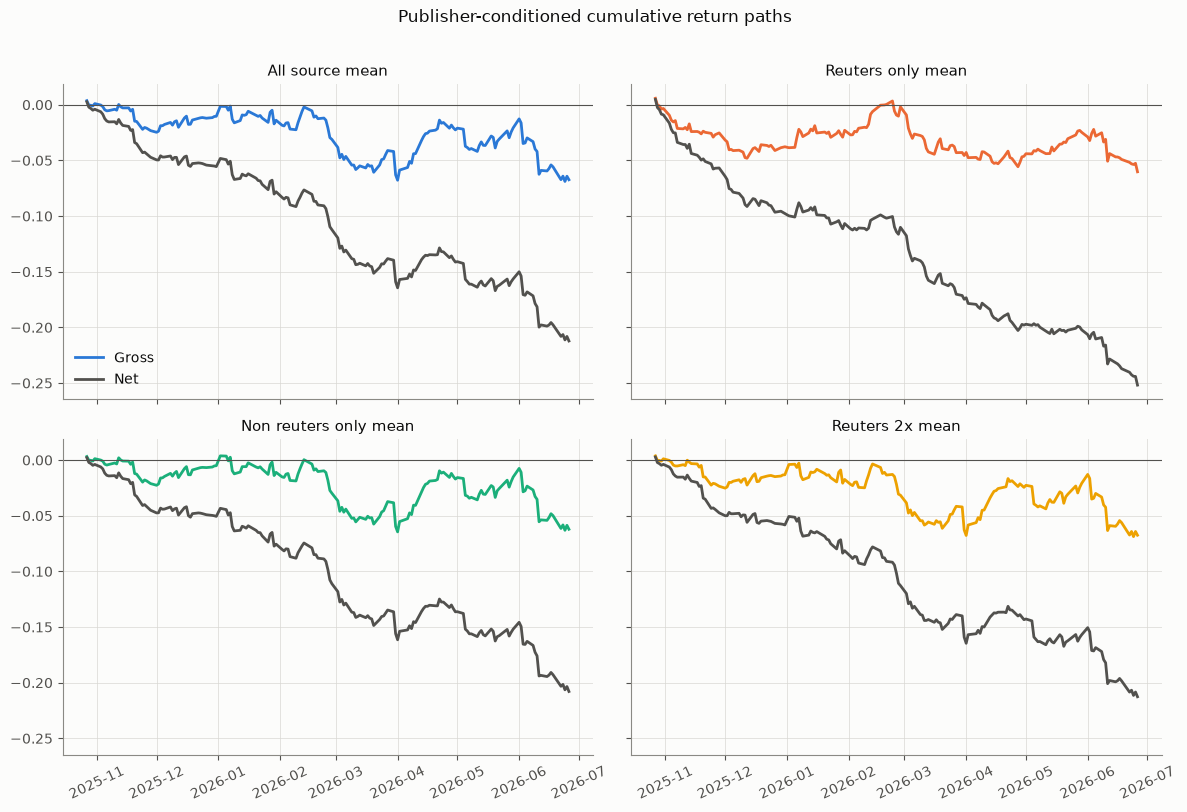

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for ax, arm, label, colour in zip(
    axes.flat,
    PUBLISHER_ARMS,
    labels,
    CATEGORICAL[:4],
    strict=True,
):
    daily = daily_outputs[arm]
    gross = (1.0 + daily["gross_return"]).cumprod() - 1.0
    net = (1.0 + daily["net_return"]).cumprod() - 1.0
    ax.plot(daily["session_date"], gross, color=colour, label="Gross")
    ax.plot(daily["session_date"], net, color=INK["secondary"], label="Net")
    ax.axhline(0, color=INK["reference"], linewidth=0.8)
    ax.set_title(label)
    ax.tick_params(axis="x", rotation=25)
axes[0, 0].legend()
fig.suptitle("Publisher-conditioned cumulative return paths", y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT / "publisher_equity_curves.png", dpi=160, bbox_inches="tight")
plt.show()

## 4. Verdict and next gate

Passing this retrospective arm would support replication on a new untouched
window; it would not turn source codes into causal publisher-quality effects.
Failure closes publisher weighting on the present window rather than inviting
more source-code tiers or weights.

In [10]:
survivors = int(results["bh_reject_ic_q05"].sum())
viable = int(results["economically_viable"].sum())
best_gross = results.sort_values("sharpe_gross", ascending=False).iloc[0]
if viable:
    verdict = (
        "FEASIBILITY SIGNAL ONLY: at least one publisher arm clears the frozen "
        "retrospective gates; replication on a new untouched window is required."
    )
elif survivors:
    verdict = (
        "STATISTICAL BUT NOT ECONOMIC: at least one publisher IC survives BH, "
        "but no arm clears the full economic gate."
    )
else:
    verdict = (
        "CLEAN NULL: no publisher-conditioned IC survives BH and no arm clears "
        "the economic gate; do not search more source tiers or weights here."
    )

verdict_table = pd.DataFrame(
    [
        {"item": "BH survivors", "value": survivors},
        {"item": "economically viable arms", "value": viable},
        {"item": "best gross-Sharpe arm", "value": best_gross["arm"]},
        {"item": "best gross Sharpe", "value": float(best_gross["sharpe_gross"])},
        {
            "item": "best break-even bps/side",
            "value": float(results["breakeven_bps_per_side"].max()),
        },
        {"item": "verdict", "value": verdict},
    ]
)
verdict_table.to_csv(OUTPUT / "verdict.csv", index=False)
display(verdict_table)
print(verdict)

,item,value
0,BH survivors,0
1,economically viable arms,0
2,best gross-Sharpe arm,non_reuters_only_mean
3,best gross Sharpe,-1.102714
4,best break-even bps/side,-2.658179
5,verdict,CLEAN NULL: no publisher-conditioned IC surviv...


CLEAN NULL: no publisher-conditioned IC survives BH and no arm clears the economic gate; do not search more source tiers or weights here.


In [11]:
manifest = {
    "status": "completed",
    "analysis_status": "retrospective_non_pooled_expanded_lseg_robustness",
    "input": {
        "gemma_score_path": str(GEMMA_SCORES.relative_to(REPO_ROOT)),
        "gemma_score_sha256": score_audit["output_sha256"],
        "merged_headline_path": str(MERGED_HEADLINES.relative_to(REPO_ROOT)),
        "merged_headline_sha256": source_audit["corpus_sha256"],
        "unique_successes": score_audit["unique_successes"],
    },
    "design": {
        "arms": list(PUBLISHER_ARMS),
        "reuters_source_code": REUTERS_SOURCE_CODE,
        "other_source_policy": "unresolved non-Reuters pool; no inferred tiers",
        "source_specific_earliest_timestamps": True,
        "outcome": "split-adjusted non-dividend-adjusted raw open-to-next-open return",
        "cost_bps_per_side": PUBLISHER_COST_BPS_PER_SIDE,
        "multiplicity_family": PUBLISHER_PRIMARY_FAMILY,
        "bootstrap": {
            "block_length_sessions": 5,
            "replications": PUBLISHER_BOOTSTRAP_REPLICATIONS,
            "seed": PUBLISHER_SEED,
        },
    },
    "coverage": {
        key: value
        for key, value in source_audit.items()
        if key not in {"source_row_counts", "corpus_sha256"}
    },
    "result": {
        "bh_survivors": survivors,
        "economically_viable_arms": viable,
        "best_gross_sharpe_arm": str(best_gross["arm"]),
        "best_gross_sharpe": float(best_gross["sharpe_gross"]),
        "best_breakeven_bps_per_side": float(
            results["breakeven_bps_per_side"].max()
        ),
        "verdict": verdict,
    },
    "limitations": [
        "already-open eight-month return window",
        "publisher identity resolved only for NS:RTRS",
        "source association is observational and may reflect story selection/syndication",
        "LSEG regime is separate from and not pooled with FNSPID",
    ],
    "licence_boundary": "no headline text written to notebook outputs",
}
(OUTPUT / "manifest.json").write_text(
    json.dumps(manifest, indent=2, sort_keys=True) + "\n", encoding="utf-8"
)
manifest

{'status': 'completed',
 'analysis_status': 'retrospective_non_pooled_expanded_lseg_robustness',
 'input': {'gemma_score_path': 'Data/collections/lseg_us_sector_44_8m_headlines/derived/headline_scores_gemma4_26b_a4b_it_deepinfra_fp8_investor_headline_soft_label_v1.csv',
  'gemma_score_sha256': 'afb2d9c3029c4fba4fce3600218233a02d14051788f87313fd49c9da681c6d2f',
  'merged_headline_path': 'Data/collections/lseg_us_sector_44_8m_headlines/derived/merged/headlines.jsonl',
  'merged_headline_sha256': '7f48c46690f3293cbfe846ddecc701852daf3c35643f2747dcbc39f829927878',
  'unique_successes': 888155},
 'design': {'arms': ['all_source_mean',
   'reuters_only_mean',
   'non_reuters_only_mean',
   'reuters_2x_mean'],
  'reuters_source_code': 'NS:RTRS',
  'other_source_policy': 'unresolved non-Reuters pool; no inferred tiers',
  'source_specific_earliest_timestamps': True,
  'outcome': 'split-adjusted non-dividend-adjusted raw open-to-next-open return',
  'cost_bps_per_side': 10.0,
  'multiplicity_fa